# Carregamento do DataSet

In [10]:
%reload_ext autoreload
%autoreload 2

from variables import filenames, features, target
from load_dataset import load
from pre_processing import apply, ReplaceInfWithNan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = load(filenames)
df = apply(df)
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


# Preprocessamento

# Analise do Dataset

In [13]:
df.drop(columns=["Destination Port"], inplace=True)
df.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,109,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,52,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,34,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
# Muda os ataques para categorias mais genéricas, para facilitar a visualização e o entendimento dos dados
#print("Unique labels before mapping:", df['Label'].unique())
#attack_mapping = {
#    'BENIGN': 'Benign',
#    'DDoS': 'DDoS',
#    'PortScan': 'Port Scan',
#    'Bot': 'Bot',
#    'Infiltration': 'Infiltration',
#    'Web Attack � Brute Force': 'Web Attack',
#    'Web Attack � XSS': 'Web Attack',
#    'Web Attack � Sql Injection': 'Web Attack',
#    'FTP-Patator': 'Bruteforce',
#    'SSH-Patator': 'Bruteforce',
#    'DoS slowloris': 'DoS',
#    'DoS Slowhttptest': 'DoS',
#    'DoS Hulk': 'DoS',
#    'DoS GoldenEye': 'DoS',
#    'Heartbleed': 'Heartbleed'
#}
#
#df['Label'] = df['Label'].map(attack_mapping)
#print("\n\nUnique labels after mapping:", df['Label'].unique())


In [14]:
df = df[df['Label'].isin(['BENIGN','DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye'])]
df['Label'].value_counts()

Label
BENIGN              2096484
DoS Hulk             172849
DoS GoldenEye         10286
DoS slowloris          5385
DoS Slowhttptest       5228
Name: count, dtype: int64

In [7]:
# Muda os ataques para categorias mais genéricas, para facilitar a visualização e o entendimento dos dados
print("Unique labels before mapping:", df['Label'].unique())
attack_mapping = {
    'BENIGN': 'Benign',
    'DDoS': 'DDoS',
    'DoS slowloris': 'DoS - Slowloris',
    'DoS Slowhttptest': 'DoS - Slowhttptest',
    'DoS Hulk': 'DoS - Hulk',
    'DoS GoldenEye': 'DoS - GoldenEye'
}

df['Label'] = df['Label'].map(attack_mapping)
print("\n\nUnique labels after mapping:", df['Label'].unique())

Unique labels before mapping: ['BENIGN' 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye']


Unique labels after mapping: ['Benign' 'DoS - Slowloris' 'DoS - Slowhttptest' 'DoS - Hulk'
 'DoS - GoldenEye']


In [15]:
df['Label'].value_counts()

Label
BENIGN              2096484
DoS Hulk             172849
DoS GoldenEye         10286
DoS slowloris          5385
DoS Slowhttptest       5228
Name: count, dtype: int64

In [16]:
# Variância de todas as colunas numéricas
cols = df.columns.drop("Label", errors="ignore")
variancias = df[cols].select_dtypes(include=np.number).var().sort_values()

# Lista das colunas com variância 0 (ou muito próxima de 0)
colunas_variancia_zero = variancias[np.isclose(variancias, 0.0)].index.tolist()

print("\nColunas com variância igual a 0 (ou muito próxima de 0):")
print(colunas_variancia_zero)

# Remove essas colunas do DataFrame
df = df.drop(columns=colunas_variancia_zero, errors="ignore")
print(f"\nTotal de colunas removidas: {len(colunas_variancia_zero)}")

/home/alfredolsn/Documents/Suricata_ML/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)



Colunas com variância igual a 0 (ou muito próxima de 0):
['Fwd Avg Packets/Bulk', 'Bwd URG Flags', 'Bwd PSH Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

Total de colunas removidas: 8


In [17]:
col1, col2 = "Fwd Header Length", "Fwd Header Length.1"

if col1 not in df.columns or col2 not in df.columns:
    print(f"Coluna ausente. Disponíveis? {col1 in df.columns=}, {col2 in df.columns=}")
else:
    iguais = df[col1].equals(df[col2])  # compara considerando NaN na mesma posição como igual
    print(f"As colunas '{col1}' e '{col2}' são totalmente iguais? {iguais}")

    mask_diff = ~(df[col1].eq(df[col2]) | (df[col1].isna() & df[col2].isna()))
    qtd_diff = int(mask_diff.sum())
    total = len(df)

    print(f"Total de linhas: {total}")
    print(f"Linhas diferentes: {qtd_diff} ({(qtd_diff/total)*100:.6f}%)")

    if qtd_diff > 0:
        print("\nExemplos de diferenças:")
        display(df.loc[mask_diff, [col1, col2]].head(10))

As colunas 'Fwd Header Length' e 'Fwd Header Length.1' são totalmente iguais? True
Total de linhas: 2290232
Linhas diferentes: 0 (0.000000%)


In [18]:
#Remover a coluna "Fwd Header Length.1" por ser idêntica à "Fwd Header Length"
if "Fwd Header Length.1" in df.columns:
    df.drop(columns=["Fwd Header Length.1"], inplace=True)
    print("Coluna 'Fwd Header Length.1' removida por ser idêntica a 'Fwd Header Length'.")

Coluna 'Fwd Header Length.1' removida por ser idêntica a 'Fwd Header Length'.


In [19]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["Class"] = label_encoder.fit_transform(df["Label"].astype(str))

mapa_classes = pd.DataFrame({
    "Label": label_encoder.classes_,
    "Class": range(len(label_encoder.classes_))
})

display(mapa_classes)

,Label,Class
0,BENIGN,0
1,DoS GoldenEye,1
2,DoS Hulk,2
3,DoS Slowhttptest,3
4,DoS slowloris,4


In [20]:
df.drop(columns=["Label"], inplace=True)

## Separação Treino/Teste


In [21]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.20, random_state=42, stratify=df['Class'])

## Balanceamento

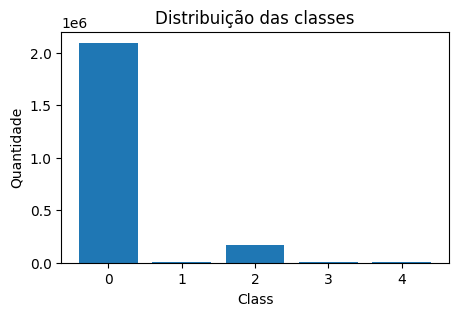

In [14]:
def plot_class_distribution(df, class_col="Class"):
    counts = df[class_col].value_counts().sort_index()
    plt.figure(figsize=(5,3))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title("Distribuição das classes")
    plt.xlabel("Class")
    plt.ylabel("Quantidade")
    plt.show()
plot_class_distribution(df)

In [16]:
df['Class'].value_counts()

Class
0    2096484
2     172849
1      10286
4       5385
3       5228
Name: count, dtype: int64

In [17]:
classe_benign = df[df["Class"] == 0]
classe_dos_goldeneye = df[df["Class"] == 1]
classe_dos_hulk = df[df["Class"] == 2]
classe_dos_slowhttptest = df[df["Class"] == 3]
classe_dos_slowloris = df[df["Class"] == 4]





min_count = min(len(classe_benign), len(classe_dos_goldeneye), len(classe_dos_hulk), len(classe_dos_slowhttptest), len(classe_dos_slowloris))

# Faz o undersample da classe maior
    
classe_benign_sample = classe_benign.sample(n=min_count, random_state=42)
classe_dos_goldeneye_sample = classe_dos_goldeneye.sample(n=min_count, random_state=42)
classe_dos_hulk_sample = classe_dos_hulk.sample(n=min_count, random_state=42)
classe_dos_slowhttptest_sample = classe_dos_slowhttptest.sample(n=min_count, random_state=42)
classe_dos_slowloris_sample = classe_dos_slowloris.sample(n=min_count, random_state=42)

# Junta as duas classes
df_undersampled = pd.concat([classe_benign_sample, classe_dos_goldeneye_sample, classe_dos_hulk_sample, classe_dos_slowhttptest_sample, classe_dos_slowloris_sample])

# Embaralha o resultado
df_undersampled = df_undersampled.sample(frac=1, random_state=42).reset_index(drop=True)

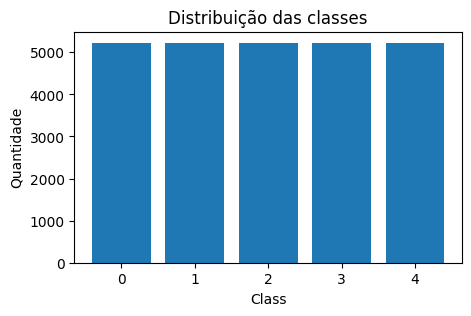

In [18]:
plot_class_distribution(df_undersampled)

# Treinamento

In [25]:
X_train = df_train.drop(columns=["Class"])
y_train = df_train["Class"]

X_test = df_test.drop(columns=["Class"])
y_test = df_test["Class"]

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from pre_processing import ReplaceInfWithNan

model = Pipeline(steps=[
    ("replace_inf", ReplaceInfWithNan()),
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(random_state=42, n_estimators=100, warm_start=True))
])

In [30]:
from tqdm import tqdm
import time

start = time.time()
model.fit(X_train, y_train)
end = time.time()
print(f"Treinamento concluído em {end - start:.2f} segundos")

Treinamento concluído em 955.03 segundos


## Salvamento do Modelo e Scaler

In [31]:
import joblib
import os 

#Cria a pasta modelo caso não exista
os.makedirs("modelo", exist_ok=True)

# Salvar o modelo treinado
joblib.dump(model, "./modelo/pipeline.joblib")

# Salvar o LabelEncoder
joblib.dump(label_encoder, "modelo/label_encoder.joblib")

# Salvar o scaler
#joblib.dump(scaler, "modelo/minmax_scaler.joblib")

['modelo/label_encoder.joblib']

## Avaliação do Modelo

In [32]:
y_predict = model.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

def show_classification_metrics(y_true, y_pred):
    print("Acurácia:", accuracy_score(y_true, y_pred))
    print("Precisão:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))
    print("\nRelatório de Classificação:")
    print(classification_report(y_true, y_pred))

    # Matriz de confusão gráfica
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.title('Matriz de Confusão')
    plt.show()

def plot_roc_auc(y_true, y_pred_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    auc = roc_auc_score(y_true, y_pred_proba)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('FPR (False Positive Rate)')
    plt.ylabel('TPR (True Positive Rate)')
    plt.title('Curva ROC')
    plt.legend(loc='lower right')
    plt.show()
    print(f'AUC: {auc:.4f}')

Acurácia: 0.9993690603802666
Precisão: 0.9993722038720768
Recall: 0.9993690603802666
F1 Score: 0.9993700292926503

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419297
           1       1.00      0.99      1.00      2057
           2       1.00      1.00      1.00     34570
           3       0.95      0.99      0.97      1046
           4       1.00      1.00      1.00      1077

    accuracy                           1.00    458047
   macro avg       0.99      0.99      0.99    458047
weighted avg       1.00      1.00      1.00    458047



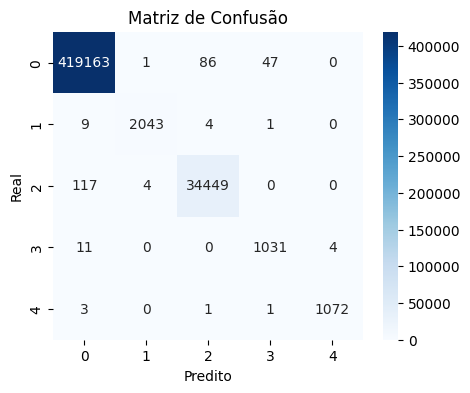

In [34]:
show_classification_metrics(y_test, y_predict)